# **Import Required Libraries**

---



In [129]:
# Importing the pandas library to manipulate data
import pandas as pd

# Importing the numpy library for numerical operations
import numpy as np

# Importing resample for class balancing
from sklearn.utils import resample

# To split the data into training and test groups
from sklearn.model_selection import train_test_split

# Machine learning task framework
import tensorflow as tf

# Metrics for assessing model performance
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Importing GridSearchCV to discover strong hyperparameters for models
from sklearn.model_selection import GridSearchCV

# Scikit-learn wrapper for Keras models (Keras 3 compatible)
from keras.wrappers import SKLearnClassifier

# For the step-by-step development of neural networks
from tensorflow.keras.models import Sequential

# Importing neural network subcomponents
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Dropout

# For normalizing the data to ensure consistent scaling
from sklearn.preprocessing import MinMaxScaler

# For creating organized and clear result tables
from prettytable import PrettyTable

# Configure random seeding for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [130]:
from pathlib import Path
import glob

root_path = Path('/Users/yuepan/Desktop/Campbell-B')

# Load price data from features_merged.csv
combined_data = pd.read_csv(root_path / 'Files/code/data/features_merged.csv')
combined_data.columns = [c.strip().lower() for c in combined_data.columns]
combined_data['date'] = pd.to_datetime(combined_data['date']).dt.date
combined_data['Volume BTC'] = combined_data['volume']
combined_data['Volume USD'] = combined_data['volume'] * combined_data['close']

# Sentiment dataset: Nexus Uni + CrudeBERT merged only
nexus_uni_path = root_path / 'Files/code/final_analysis/Crudebert_results/nexus_uni_crudebert_merged.csv'
Sentiment_Scores = pd.read_csv(nexus_uni_path)
print(f'Loaded {nexus_uni_path.name} ({len(Sentiment_Scores)} rows)')

# Normalize date — handle both timezone-aware and naive
Sentiment_Scores['date'] = pd.to_datetime(Sentiment_Scores['date'], utc=True, format='mixed').dt.tz_convert(None).dt.date

# Normalize sentiment fields
Sentiment_Scores['sentiment'] = Sentiment_Scores['sentiment'].astype(str).str.strip().str.lower()
sentiment_to_score = {'positive': 1, 'neutral': 0, 'negative': -1}
Sentiment_Scores['BERT_compound'] = Sentiment_Scores['sentiment'].map(sentiment_to_score).fillna(0) * Sentiment_Scores['confidence'].fillna(0)
Sentiment_Scores['sentiment'] = Sentiment_Scores['sentiment'].map(sentiment_to_score).fillna(0)

# De-duplicate on (date, title)
Sentiment_Scores = Sentiment_Scores.drop_duplicates(subset=["date", "title"]).reset_index(drop=True)

print(f'\nTotal sentiment rows: {len(Sentiment_Scores)}')
print(f'Date range: {min(Sentiment_Scores["date"])} to {max(Sentiment_Scores["date"])}')


Loaded nexus_uni_crudebert_merged.csv (12612 rows)

Total sentiment rows: 12612
Date range: 2015-01-01 to 2026-04-11


# **Overview the Data**

---



In [131]:
combined_data.head()

,date,close,high,low,open,volume,ret,sma_20,sma_50,adx_14,...,sp500_open,sp500_volume,sp500_ret,vix_open,vix_high,vix_low,vix_close,ovx,Volume BTC,Volume USD
0,2005-01-03,42.119999,43.099998,41.250000,43.099998,69484,NaN,NaN,NaN,NaN,...,1211.920044,1510800000,-0.008119,13.39,14.23,13.25,14.08,NaN,69484,2.926666e+06
1,2005-01-04,43.910000,44.130001,41.849998,42.180000,100665,0.042498,NaN,NaN,NaN,...,1202.079956,1721000000,-0.011671,14.01,14.45,13.93,13.98,NaN,100665,4.420200e+06
2,2005-01-05,43.389999,44.000000,42.599998,43.900002,91011,-0.011842,NaN,NaN,NaN,...,1188.050049,1738900000,-0.003628,13.98,14.09,13.26,14.09,NaN,91011,3.948967e+06
3,2005-01-06,45.560001,45.750000,42.799999,43.389999,122411,0.050012,NaN,NaN,NaN,...,1183.739990,1569100000,0.003506,14.09,14.09,13.33,13.58,NaN,122411,5.577045e+06
4,2005-01-07,45.430000,46.099998,44.750000,45.500000,99725,-0.002853,NaN,NaN,NaN,...,1187.890015,1477900000,-0.001431,13.47,13.51,12.94,13.49,NaN,99725,4.530507e+06


# **Drop Unnecessary Columns**

---



In [132]:
combined_data = combined_data.drop(['unix', 'symbol'], axis=1, errors='ignore')


In [133]:
print(combined_data.columns)

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'ret', 'sma_20',
       'sma_50', 'adx_14', 'rsi_14', 'macd_line', 'macd_signal',
       'macd_histogram', 'treasury_yield_10year_daily', 'fed_funds_daily',
       'unemployment_rate', 'cpi_monthly', 'sp500_close', 'sp500_high',
       'sp500_low', 'sp500_open', 'sp500_volume', 'sp500_ret', 'vix_open',
       'vix_high', 'vix_low', 'vix_close', 'ovx', 'Volume BTC', 'Volume USD'],
      dtype='object')


In [134]:
combined_data.head()

,date,close,high,low,open,volume,ret,sma_20,sma_50,adx_14,...,sp500_open,sp500_volume,sp500_ret,vix_open,vix_high,vix_low,vix_close,ovx,Volume BTC,Volume USD
0,2005-01-03,42.119999,43.099998,41.250000,43.099998,69484,NaN,NaN,NaN,NaN,...,1211.920044,1510800000,-0.008119,13.39,14.23,13.25,14.08,NaN,69484,2.926666e+06
1,2005-01-04,43.910000,44.130001,41.849998,42.180000,100665,0.042498,NaN,NaN,NaN,...,1202.079956,1721000000,-0.011671,14.01,14.45,13.93,13.98,NaN,100665,4.420200e+06
2,2005-01-05,43.389999,44.000000,42.599998,43.900002,91011,-0.011842,NaN,NaN,NaN,...,1188.050049,1738900000,-0.003628,13.98,14.09,13.26,14.09,NaN,91011,3.948967e+06
3,2005-01-06,45.560001,45.750000,42.799999,43.389999,122411,0.050012,NaN,NaN,NaN,...,1183.739990,1569100000,0.003506,14.09,14.09,13.33,13.58,NaN,122411,5.577045e+06
4,2005-01-07,45.430000,46.099998,44.750000,45.500000,99725,-0.002853,NaN,NaN,NaN,...,1187.890015,1477900000,-0.001431,13.47,13.51,12.94,13.49,NaN,99725,4.530507e+06


#**Check Missing Values**

---

Following that, we checked the 'combined_data' dataset for missing value.

In [135]:
missing_count = combined_data.isna().sum()
print(missing_count)

date                              0
close                             0
high                              0
low                               0
open                              0
volume                            0
ret                               1
sma_20                           19
sma_50                           49
adx_14                           26
rsi_14                           14
macd_line                        25
macd_signal                      33
macd_histogram                   33
treasury_yield_10year_daily      39
fed_funds_daily                   0
unemployment_rate                19
cpi_monthly                      19
sp500_close                       0
sp500_high                        0
sp500_low                         0
sp500_open                        0
sp500_volume                      0
sp500_ret                         0
vix_open                          0
vix_high                          0
vix_low                           0
vix_close                   

According to the result, we can confirm that there are no missing values in the dataset.

# **Check Duplicates**

---
Then, we examined the ‘combined_data’ dataset for duplicates.



In [136]:
num_duplicates = combined_data.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [137]:
combined_data['date'] = pd.to_datetime(combined_data['date'])
combined_data = combined_data.sort_values('date').reset_index(drop=True)

combined_daily = combined_data.copy()

print(combined_daily.shape)
combined_daily.head()

(5307, 31)


,date,close,high,low,open,volume,ret,sma_20,sma_50,adx_14,...,sp500_open,sp500_volume,sp500_ret,vix_open,vix_high,vix_low,vix_close,ovx,Volume BTC,Volume USD
0,2005-01-03,42.119999,43.099998,41.250000,43.099998,69484,NaN,NaN,NaN,NaN,...,1211.920044,1510800000,-0.008119,13.39,14.23,13.25,14.08,NaN,69484,2.926666e+06
1,2005-01-04,43.910000,44.130001,41.849998,42.180000,100665,0.042498,NaN,NaN,NaN,...,1202.079956,1721000000,-0.011671,14.01,14.45,13.93,13.98,NaN,100665,4.420200e+06
2,2005-01-05,43.389999,44.000000,42.599998,43.900002,91011,-0.011842,NaN,NaN,NaN,...,1188.050049,1738900000,-0.003628,13.98,14.09,13.26,14.09,NaN,91011,3.948967e+06
3,2005-01-06,45.560001,45.750000,42.799999,43.389999,122411,0.050012,NaN,NaN,NaN,...,1183.739990,1569100000,0.003506,14.09,14.09,13.33,13.58,NaN,122411,5.577045e+06
4,2005-01-07,45.430000,46.099998,44.750000,45.500000,99725,-0.002853,NaN,NaN,NaN,...,1187.890015,1477900000,-0.001431,13.47,13.51,12.94,13.49,NaN,99725,4.530507e+06


According to the result, we found no duplicates in the dataset.

# **Overview the 'Sentiment_Scores' Dataset**

---



In [138]:
Sentiment_Scores.head()

,date,year,title,sentiment,confidence,BERT_compound
0,2015-01-01,2015,E.C.B. Executive Says More Eurozone Stimulus M...,1,0.962342,0.962342
1,2015-01-01,2015,Markets Hit Highs in '14 as Bull Run Endured,1,0.986332,0.986332
2,2015-01-01,2015,Market Ends a Strong Year With Modest Decline,-1,0.984913,-0.984913
3,2015-01-03,2015,Holiday footfall lifts Bed Bath & Beyond,1,0.964643,0.964643
4,2015-01-03,2015,Bed Bath & Beyond helped by holiday sales mome...,1,0.985336,0.985336


## **Merge Datasets Based on Date**

---

In this step, we combine the 'sentiment_scores' and 'combined_data' datasets into a new dataframe called 'merged_df', using the 'date' as the key, to streamline further analysis.

In [139]:
Sentiment_Scores.shape

(12612, 6)

In [140]:
Sentiment_Scores['date'] = pd.to_datetime(Sentiment_Scores['date'])
Sentiment_Scores = Sentiment_Scores.sort_values('date')

# Daily sentiment aggregation
combined_sen = Sentiment_Scores.groupby('date', as_index=False).agg(
    BERT_compound=('BERT_compound', 'mean'),
    sentiment_std=('BERT_compound', 'std'),
    article_count=('BERT_compound', 'count'),
    positive_ratio=('sentiment', lambda x: (x > 0).mean()),
    negative_ratio=('sentiment', lambda x: (x < 0).mean()),
)
combined_sen['sentiment_std'] = combined_sen['sentiment_std'].fillna(0)

print(combined_sen.shape)
combined_sen.head()

(3569, 6)


,date,BERT_compound,sentiment_std,article_count,positive_ratio,negative_ratio
0,2015-01-01,0.321254,1.131237,3,0.666667,0.333333
1,2015-01-03,0.080199,1.043233,4,0.500000,0.500000
2,2015-01-05,-0.192157,0.891855,6,0.333333,0.500000
3,2015-01-06,-0.362343,0.895803,10,0.300000,0.700000
4,2015-01-07,-0.167422,0.867873,6,0.333333,0.666667


In [141]:
combined_daily['date'] = pd.to_datetime(combined_daily['date'])
combined_sen['date'] = pd.to_datetime(combined_sen['date'])

merged_df = pd.merge(
    combined_daily,
    combined_sen,
    on='date',
    how='left'
)
merged_df = merged_df.sort_values('date').reset_index(drop=True)

# Keep rows within sentiment date range (2015+)
sent_min_date = combined_sen['date'].min()
merged_df = merged_df[merged_df['date'] >= sent_min_date].reset_index(drop=True)

# article_count=0 on no-news days; forward-fill sentiment scores only
merged_df['article_count'] = merged_df['article_count'].fillna(0)
ffill_cols = ['BERT_compound', 'sentiment_std', 'positive_ratio', 'negative_ratio']
merged_df[ffill_cols] = merged_df[ffill_cols].ffill()
merged_df = merged_df.dropna(subset=['BERT_compound']).reset_index(drop=True)

# ── Rolling sentiment features (capture trends for LSTM) ──
# Short-term sentiment momentum
merged_df['sent_ma3'] = merged_df['BERT_compound'].rolling(3, min_periods=1).mean()
merged_df['sent_ma5'] = merged_df['BERT_compound'].rolling(5, min_periods=1).mean()
merged_df['sent_ma10'] = merged_df['BERT_compound'].rolling(10, min_periods=1).mean()

# Sentiment momentum: short vs long
merged_df['sent_momentum'] = merged_df['sent_ma3'] - merged_df['sent_ma10']

# Sentiment change (1-day shift)
merged_df['sent_change'] = merged_df['BERT_compound'].diff()

# Rolling positive/negative ratio trend
merged_df['pos_ratio_ma5'] = merged_df['positive_ratio'].rolling(5, min_periods=1).mean()
merged_df['neg_ratio_ma5'] = merged_df['negative_ratio'].rolling(5, min_periods=1).mean()

# News volume signal (log to reduce skew)
merged_df['log_article_count'] = np.log1p(merged_df['article_count'])

print(merged_df.shape)
print(f'Date range: {merged_df["date"].min()} to {merged_df["date"].max()}')
print(f'BERT NaN remaining: {merged_df["BERT_compound"].isna().sum()}')
merged_df.head()

(2790, 44)
Date range: 2015-01-05 00:00:00 to 2026-02-06 00:00:00
BERT NaN remaining: 0


,date,close,high,low,open,volume,ret,sma_20,sma_50,adx_14,...,positive_ratio,negative_ratio,sent_ma3,sent_ma5,sent_ma10,sent_momentum,sent_change,pos_ratio_ma5,neg_ratio_ma5,log_article_count
0,2015-01-05,50.040001,52.730000,49.680000,52.610001,375782,-0.050294,56.8515,68.3374,60.853423,...,0.333333,0.500000,-0.192157,-0.192157,-0.192157,0.000000,NaN,0.333333,0.500000,1.945910
1,2015-01-06,47.930000,50.369999,47.549999,50.000000,451642,-0.042166,55.9560,67.6542,60.935535,...,0.300000,0.700000,-0.277250,-0.277250,-0.277250,0.000000,-0.170186,0.316667,0.600000,2.397895
2,2015-01-07,48.650002,49.310001,46.830002,48.000000,460083,0.015022,55.2360,67.0070,61.137385,...,0.333333,0.666667,-0.240641,-0.240641,-0.240641,0.000000,0.194922,0.322222,0.622222,1.945910
3,2015-01-08,48.790001,49.650002,47.730000,48.779999,362081,0.002878,54.4845,66.3628,61.055855,...,0.307692,0.692308,-0.304079,-0.276098,-0.276098,-0.027980,-0.215050,0.318590,0.639744,2.639057
4,2015-01-09,48.360001,49.610001,47.160000,48.919998,421007,-0.008813,53.8555,65.7016,61.094041,...,0.333333,0.666667,-0.308373,-0.295924,-0.295924,-0.012449,0.007246,0.321538,0.645128,1.386294


# **Derive the Target Variable**

---




In [142]:
import numpy as np

def derive_features(df):
    """Add derived features to a copy of the dataframe."""
    data = df.sort_values('date').reset_index(drop=True).copy()
    data['close_pct'] = data['close'].pct_change()
    data['open_pct'] = data['open'].pct_change()
    data['high_pct'] = data['high'].pct_change()
    data['low_pct'] = data['low'].pct_change()
    data['volume_pct'] = data['volume'].pct_change()
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data['high_low_spread'] = (data['high'] - data['low']) / data['close']
    data['close_open_spread'] = (data['close'] - data['open']) / data['close']

    # Convert level-based macro features to change-based to avoid out-of-range
    # extrapolation across folds (CPI / yield / fed funds / unemployment keep
    # drifting upward, so raw levels leak regime info).
    if 'cpi_monthly' in data.columns:
        data['cpi_pct'] = data['cpi_monthly'].pct_change().fillna(0)
    if 'treasury_yield_10year_daily' in data.columns:
        data['treasury_yield_diff'] = data['treasury_yield_10year_daily'].diff().fillna(0)
    if 'fed_funds_daily' in data.columns:
        data['fed_funds_diff'] = data['fed_funds_daily'].diff().fillna(0)
    if 'unemployment_rate' in data.columns:
        data['unemployment_diff'] = data['unemployment_rate'].diff().fillna(0)

    data['future_return'] = data['close'].shift(-5) / data['close'] - 1
    data['movement'] = data['future_return'].apply(lambda x: 0 if x <= 0 else 1)
    data.dropna(subset=['movement', 'future_return', 'close_pct'], inplace=True)
    return data

# Unified dataset for all models (BERT sentiment range) — ensures fair comparison
daily_data = derive_features(merged_df)
print('daily_data (unified):', daily_data.shape)
print(f'  Date range: {daily_data["date"].min()} to {daily_data["date"].max()}')
print(f'  Movement: {daily_data["movement"].value_counts().to_dict()}')


daily_data (unified): (2784, 57)
  Date range: 2015-01-06 00:00:00 to 2026-01-30 00:00:00
  Movement: {1: 1483, 0: 1301}


/var/folders/41/xycdqphj4z73nxh8g40rq_x40000gn/T/ipykernel_50220/3903191016.py:19: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['cpi_pct'] = data['cpi_monthly'].pct_change().fillna(0)


In [143]:
daily_data.shape

(2784, 57)

# **Check Class Balance**

---



In [144]:
# Count the occurrences of each class in the 'movement' column
class_counts = daily_data['movement'].value_counts()

# Print the counts
print(class_counts)

movement
1    1483
0    1301
Name: count, dtype: int64


As we can see the classes are not balance so we need to do class balancing using oversampling technique.

# **Oversampling**

---



In [145]:
oversampled_data = daily_data.copy()


In [146]:
'''
# Separate each class
class_zero = daily_data[daily_data['movement'] == 0]
class_one = daily_data[daily_data['movement'] == 1]

# Calculate the target number of samples per class (using the size of the majority class)
num_samples = max(len(class_zero), len(class_one))

# Oversample each class, random_state=42)
oversampled_zero = resample(class_zero, replace=True, n_samples=num_samples, random_state=42)
oversampled_one = resample(class_one, replace=True, n_samples=num_samples, random_state=42)

# Combine the oversampled classes
oversampled_data = pd.concat([oversampled_zero, oversampled_one])

# Shuffle the oversampled data
oversampled_data = oversampled_data.sample(frac=1, random_state=42)

# Check the class distribution after oversampling
oversampled_class_counts = oversampled_data['movement'].value_counts()
print(oversampled_class_counts)
'''

"\n# Separate each class\nclass_zero = daily_data[daily_data['movement'] == 0]\nclass_one = daily_data[daily_data['movement'] == 1]\n\n# Calculate the target number of samples per class (using the size of the majority class)\nnum_samples = max(len(class_zero), len(class_one))\n\n# Oversample each class, random_state=42)\noversampled_zero = resample(class_zero, replace=True, n_samples=num_samples, random_state=42)\noversampled_one = resample(class_one, replace=True, n_samples=num_samples, random_state=42)\n\n# Combine the oversampled classes\noversampled_data = pd.concat([oversampled_zero, oversampled_one])\n\n# Shuffle the oversampled data\noversampled_data = oversampled_data.sample(frac=1, random_state=42)\n\n# Check the class distribution after oversampling\noversampled_class_counts = oversampled_data['movement'].value_counts()\nprint(oversampled_class_counts)\n"

# **Define features**

---



In [147]:
# Define features for each model
# Engineered BERT features with rolling windows for temporal patterns
# Ablation B: shrink BERT to 3 non-redundant dims (see correlation diagnosis).
# Removed sent_ma3/ma5/momentum/pos_ratio_ma5/neg_ratio_ma5 (|r| 0.78-0.81 cluster).
bert_features = [
    'BERT_compound',       # daily sentiment score
    'sent_change',         # 1-day sentiment change (orthogonal to level)
    'log_article_count',   # news volume (only truly independent dim)
]

base_features = ['close_pct', 'open_pct', 'high_pct', 'low_pct', 'volume_pct',
                  'high_low_spread', 'close_open_spread']

additional_features = ['ret', 'sma_20', 'sma_50', 'adx_14', 'rsi_14',
    'macd_line', 'macd_signal', 'macd_histogram',
    'treasury_yield_diff', 'fed_funds_diff',
    'unemployment_diff', 'cpi_pct',
    'sp500_ret', 'vix_close', 'ovx']

# Non-BERT models use full date range; BERT models use sentiment-filtered range
features_combined_data = oversampled_data[base_features]
features_bert = oversampled_data[base_features + bert_features]
features_additional = oversampled_data[base_features + additional_features]
features_additional_bert = oversampled_data[base_features + additional_features + bert_features]

# Store source dataframes per feature set (needed for date-based splitting)
feature_sources = {
    'Combined': oversampled_data,
    'BERT': oversampled_data,
    'Additional': oversampled_data,
    'Additional+BERT': oversampled_data,
}

print('Features per model:')
for name, f in [('Combined', features_combined_data), ('BERT', features_bert),
                ('Additional', features_additional), ('Additional+BERT', features_additional_bert)]:
    src = feature_sources[name]
    print(f'  {name}: {f.shape[1]} features, {len(f)} rows, '
          f'date range: {src["date"].min()} to {src["date"].max()}')

Features per model:
  Combined: 7 features, 2784 rows, date range: 2015-01-06 00:00:00 to 2026-01-30 00:00:00
  BERT: 10 features, 2784 rows, date range: 2015-01-06 00:00:00 to 2026-01-30 00:00:00
  Additional: 22 features, 2784 rows, date range: 2015-01-06 00:00:00 to 2026-01-30 00:00:00
  Additional+BERT: 25 features, 2784 rows, date range: 2015-01-06 00:00:00 to 2026-01-30 00:00:00


# **Walk-Forward Cross-Validation Split**

---

We use 4 walk-forward folds with rolling training windows and 6-month test periods:

| Fold | Train Period | Test Period |
|------|-------------|-------------|
| 1 | 2015-01-01 → 2023-12-31 | 2024-01-01 → 2024-06-30 |
| 2 | 2015-07-01 → 2024-06-30 | 2024-07-01 → 2024-12-31 |
| 3 | 2016-01-01 → 2024-12-31 | 2025-01-01 → 2025-06-30 |
| 4 | 2016-07-01 → 2025-06-30 | 2025-07-01 → 2025-12-31 |

In [148]:
import pandas as pd

# Define walk-forward folds
walk_forward_folds = [
    {'train_start': '2015-01-01', 'train_end': '2023-12-31', 'test_start': '2024-01-01', 'test_end': '2024-06-30'},
    {'train_start': '2015-07-01', 'train_end': '2024-06-30', 'test_start': '2024-07-01', 'test_end': '2024-12-31'},
    {'train_start': '2016-01-01', 'train_end': '2024-12-31', 'test_start': '2025-01-01', 'test_end': '2025-06-30'},
    {'train_start': '2016-07-01', 'train_end': '2025-06-30', 'test_start': '2025-07-01', 'test_end': '2025-12-31'},
]

print(f'Walk-forward folds: {len(walk_forward_folds)}')
for i, fold in enumerate(walk_forward_folds, 1):
    print(f'\n  Fold {i}: train {fold["train_start"]} → {fold["train_end"]}, test {fold["test_start"]} → {fold["test_end"]}')
    for name, src_df in feature_sources.items():
        dates = pd.to_datetime(src_df['date'])
        train_n = ((dates >= fold['train_start']) & (dates <= fold['train_end'])).sum()
        test_n = ((dates >= fold['test_start']) & (dates <= fold['test_end'])).sum()
        print(f'    {name}: train={train_n}, test={test_n}')

Walk-forward folds: 4

  Fold 1: train 2015-01-01 → 2023-12-31, test 2024-01-01 → 2024-06-30
    Combined: train=2260, test=124
    BERT: train=2260, test=124
    Additional: train=2260, test=124
    Additional+BERT: train=2260, test=124

  Fold 2: train 2015-07-01 → 2024-06-30, test 2024-07-01 → 2024-12-31
    Combined: train=2262, test=128
    BERT: train=2262, test=128
    Additional: train=2262, test=128
    Additional+BERT: train=2262, test=128

  Fold 3: train 2016-01-01 → 2024-12-31, test 2025-01-01 → 2025-06-30
    Combined: train=2262, test=123
    BERT: train=2262, test=123
    Additional: train=2262, test=123
    Additional+BERT: train=2262, test=123

  Fold 4: train 2016-07-01 → 2025-06-30, test 2025-07-01 → 2025-12-31
    Combined: train=2260, test=129
    BERT: train=2260, test=129
    Additional: train=2260, test=129
    Additional+BERT: train=2260, test=129


# **Normalize the Data (Per-Fold)**

---

The scaler is fit on training data only to prevent data leakage.

In [149]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def create_sequences(X, y, look_back=5):
    X_seq, y_seq = [], []
    for i in range(look_back, len(X)):
        X_seq.append(X[i-look_back:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

look_back = 5

def prepare_fold_data(features_df, source_df, fold, look_back=5):
    """For a single fold: filter by date, scale on train, create sequences.
    
    Args:
        features_df: DataFrame of feature columns (aligned with source_df)
        source_df: Source DataFrame with 'date' and 'movement' columns
        fold: Dict with train_start, train_end, test_start, test_end
        look_back: Number of time steps for LSTM sequences
    """
    dates = pd.to_datetime(source_df['date'])
    y_all = source_df['movement'].values
    
    train_mask = (dates >= pd.Timestamp(fold['train_start'])) & (dates <= pd.Timestamp(fold['train_end']))
    test_mask = (dates >= pd.Timestamp(fold['test_start'])) & (dates <= pd.Timestamp(fold['test_end']))
    
    train_features = features_df[train_mask.values].copy()
    test_features = features_df[test_mask.values].copy()
    y_train_raw = y_all[train_mask.values]
    y_test_raw = y_all[test_mask.values]
    
    # Drop NaN rows
    train_clean = ~train_features.isnull().any(axis=1)
    test_clean = ~test_features.isnull().any(axis=1)
    
    train_features_clean = train_features[train_clean].values
    test_features_clean = test_features[test_clean].values
    y_train_clean = y_train_raw[train_clean.values]
    y_test_clean = y_test_raw[test_clean.values]
    
    # Scale: fit on train only
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_features_clean)
    test_scaled = scaler.transform(test_features_clean)
    
    # Create sequences
    X_train_seq, y_train_seq = create_sequences(train_scaled, y_train_clean, look_back)
    X_test_seq, y_test_seq = create_sequences(test_scaled, y_test_clean, look_back)
    
    return X_train_seq, X_test_seq, y_train_seq, y_test_seq, scaler

print('Fold preparation function defined.')

Fold preparation function defined.


# **Prepare Data for All Folds**

---

For each of the 4 walk-forward folds and each feature set, we split by date, scale, and create LSTM sequences.

In [150]:
# Prepare data for all folds and all feature sets
feature_sets = {
    'Combined': features_combined_data,
    'BERT': features_bert,
    'Additional': features_additional,
    'Additional+BERT': features_additional_bert,
}

# fold_data[fold_idx][model_name] = (X_train, X_test, y_train, y_test, scaler)
fold_data = {}

for fold_idx, fold in enumerate(walk_forward_folds):
    fold_data[fold_idx] = {}
    print(f'\n--- Fold {fold_idx + 1}: train {fold["train_start"]} to {fold["train_end"]}, '
          f'test {fold["test_start"]} to {fold["test_end"]} ---')
    for name, feat_df in feature_sets.items():
        src_df = feature_sources[name]
        X_tr, X_te, y_tr, y_te, sc = prepare_fold_data(
            feat_df, src_df, fold, look_back
        )
        fold_data[fold_idx][name] = (X_tr, X_te, y_tr, y_te, sc)
        print(f'  {name}: X_train={X_tr.shape}, X_test={X_te.shape}, '
              f'y_train={y_tr.shape} (pos={sum(y_tr==1)}), y_test={y_te.shape} (pos={sum(y_te==1)})')


--- Fold 1: train 2015-01-01 to 2023-12-31, test 2024-01-01 to 2024-06-30 ---
  Combined: X_train=(2254, 5, 7), X_test=(119, 5, 7), y_train=(2254,) (pos=1219), y_test=(119,) (pos=72)
  BERT: X_train=(2254, 5, 10), X_test=(119, 5, 10), y_train=(2254,) (pos=1219), y_test=(119,) (pos=72)
  Additional: X_train=(2254, 5, 22), X_test=(119, 5, 22), y_train=(2254,) (pos=1219), y_test=(119,) (pos=72)
  Additional+BERT: X_train=(2254, 5, 25), X_test=(119, 5, 25), y_train=(2254,) (pos=1219), y_test=(119,) (pos=72)

--- Fold 2: train 2015-07-01 to 2024-06-30, test 2024-07-01 to 2024-12-31 ---
  Combined: X_train=(2256, 5, 7), X_test=(123, 5, 7), y_train=(2256,) (pos=1223), y_test=(123,) (pos=58)
  BERT: X_train=(2256, 5, 10), X_test=(123, 5, 10), y_train=(2256,) (pos=1223), y_test=(123,) (pos=58)
  Additional: X_train=(2256, 5, 22), X_test=(123, 5, 22), y_train=(2256,) (pos=1223), y_test=(123,) (pos=58)
  Additional+BERT: X_train=(2256, 5, 25), X_test=(123, 5, 25), y_train=(2256,) (pos=1223), y_t

# **Hyperparameter Tuning**

---



In [151]:
import numpy as np
from itertools import product
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

num_classes = 2

param_grid = {
    'num_neurons': [16, 32],
    'dropout_rate': [0.4, 0.5],
    'activation': ['tanh']
}

def create_lstm_model_hyper(num_neurons=32, dropout_rate=0.4, activation='tanh', input_shape=None):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(LSTM(num_neurons, activation=activation, kernel_regularizer=l2(0.01)))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(
        optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def run_hyperparameter_search(X_train, y_train, model_name='Model'):
    input_shape = (X_train.shape[1], X_train.shape[2])
    tscv = TimeSeriesSplit(n_splits=3)

    best_score = -1
    best_params = None

    all_params = list(product(
        param_grid['num_neurons'],
        param_grid['dropout_rate'],
        param_grid['activation']
    ))

    for num_neurons, dropout_rate, activation in all_params:
        fold_scores = []

        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            model = create_lstm_model_hyper(
                num_neurons=num_neurons,
                dropout_rate=dropout_rate,
                activation=activation,
                input_shape=input_shape
            )

            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=5,
                restore_best_weights=True
            )

            model.fit(
                X_tr, y_tr,
                validation_data=(X_val, y_val),
                epochs=50,
                batch_size=64,
                verbose=0,
                callbacks=[early_stop]
            )

            y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
            acc = accuracy_score(y_val, y_pred)
            fold_scores.append(acc)

        mean_score = np.mean(fold_scores)
        print({
            'model': model_name,
            'num_neurons': num_neurons,
            'dropout_rate': dropout_rate,
            'cv_accuracy': round(mean_score, 4)
        })

        if mean_score > best_score:
            best_score = mean_score
            best_params = {
                'num_neurons': num_neurons,
                'dropout_rate': dropout_rate,
                'activation': activation
            }

    print(f'Best Parameters for {model_name}:', best_params)
    print(f'Best CV Accuracy for {model_name}:', round(best_score, 4))

    return best_params, best_score


In [152]:
'''
best_params_combined, best_score_combined = run_hyperparameter_search(
    X_train_combined_scaled, y_train_combined, model_name="Combined Model"
)

best_params_bert, best_score_bert = run_hyperparameter_search(
    X_train_bert_scaled, y_train_bert, model_name="BERT Model"
)

best_params_additional, best_score_additional = run_hyperparameter_search(
    X_train_additional_scaled, y_train_additional, model_name="Additional Model"
)

best_params_additional_bert, best_score_additional_bert = run_hyperparameter_search(
    X_train_additional_bert_scaled, y_train_additional_bert, model_name="Additional+BERT Model"
)
'''

'\nbest_params_combined, best_score_combined = run_hyperparameter_search(\n    X_train_combined_scaled, y_train_combined, model_name="Combined Model"\n)\n\nbest_params_bert, best_score_bert = run_hyperparameter_search(\n    X_train_bert_scaled, y_train_bert, model_name="BERT Model"\n)\n\nbest_params_additional, best_score_additional = run_hyperparameter_search(\n    X_train_additional_scaled, y_train_additional, model_name="Additional Model"\n)\n\nbest_params_additional_bert, best_score_additional_bert = run_hyperparameter_search(\n    X_train_additional_bert_scaled, y_train_additional_bert, model_name="Additional+BERT Model"\n)\n'

# **Train the Models**

---



In [153]:
from sklearn.utils.class_weight import compute_class_weight
import os, random
import tensorflow as tf

# Best hyperparameters (same as before)
best_params = {
    'Combined':        {'num_neurons': 32, 'dropout_rate': 0.4, 'activation': 'tanh'},
    'BERT':            {'num_neurons': 32, 'dropout_rate': 0.4, 'activation': 'tanh'},
    'Additional':      {'num_neurons': 32, 'dropout_rate': 0.4, 'activation': 'tanh'},
    'Additional+BERT': {'num_neurons': 32, 'dropout_rate': 0.4, 'activation': 'tanh'},
}

SEEDS = [42, 2024, 7, 1337, 99]  # 5 seeds; adjust if too slow

def make_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]

def reset_seeds(seed):
    """Fully deterministic RNG state across python/numpy/tf."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        tf.keras.utils.set_random_seed(seed)
    except Exception:
        pass
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

# Store averaged predicted probabilities per (fold, model)
fold_preds = {}         # fold_idx -> model_name -> avg proba (n_test, n_classes)
fold_histories = {}     # fold_idx -> model_name -> history of the last seed (for loss plots)

for fold_idx, fold in enumerate(walk_forward_folds):
    print(f'\n{"="*60}')
    print(f'FOLD {fold_idx + 1}: train {fold["train_start"]} → {fold["train_end"]}, '
          f'test {fold["test_start"]} → {fold["test_end"]}')
    print(f'{"="*60}')

    fold_preds[fold_idx] = {}
    fold_histories[fold_idx] = {}

    for model_name in ['Combined', 'BERT', 'Additional', 'Additional+BERT']:
        X_train, X_test, y_train, y_test = fold_data[fold_idx][model_name][:4]

        classes = np.unique(y_train)
        class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
        class_weight_dict = dict(zip(classes, class_weights))

        params = best_params[model_name]
        input_shape = (X_train.shape[1], X_train.shape[2])

        cw_str = {k: round(v, 3) for k, v in class_weight_dict.items()}
        print(f'\n  Training {model_name} (input_shape={input_shape}, '
              f'train={X_train.shape[0]}, test={X_test.shape[0]}, '
              f'class_weights={cw_str}) over {len(SEEDS)} seeds...')

        proba_sum = None
        last_history = None
        for seed in SEEDS:
            reset_seeds(seed)
            model = create_lstm_model_hyper(
                num_neurons=params['num_neurons'],
                dropout_rate=params['dropout_rate'],
                activation=params['activation'],
                input_shape=input_shape
            )
            history = model.fit(
                X_train, y_train,
                epochs=50, batch_size=32,
                validation_data=(X_test, y_test),
                verbose=0, class_weight=class_weight_dict,
                callbacks=make_callbacks()
            )
            proba = model.predict(X_test, verbose=0)
            proba_sum = proba if proba_sum is None else proba_sum + proba
            last_history = history

        avg_proba = proba_sum / len(SEEDS)
        fold_preds[fold_idx][model_name] = avg_proba
        fold_histories[fold_idx][model_name] = last_history
        print(f'    avg proba shape: {avg_proba.shape}')

print('\nAll folds trained (multi-seed averaged).')



FOLD 1: train 2015-01-01 → 2023-12-31, test 2024-01-01 → 2024-06-30

  Training Combined (input_shape=(5, 7), train=2254, test=119, class_weights={np.int64(0): np.float64(1.089), np.int64(1): np.float64(0.925)}) over 5 seeds...


E0000 00:00:1776128839.255729 1836427 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
E0000 00:00:1776128845.053978 1836427 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

    avg proba shape: (119, 2)

  Training BERT (input_shape=(5, 10), train=2254, test=119, class_weights={np.int64(0): np.float64(1.089), np.int64(1): np.float64(0.925)}) over 5 seeds...


E0000 00:00:1776128863.330003 1836427 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
E0000 00:00:1776128869.137956 1836427 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

    avg proba shape: (119, 2)

  Training Additional (input_shape=(5, 22), train=2254, test=119, class_weights={np.int64(0): np.float64(1.089), np.int64(1): np.float64(0.925)}) over 5 seeds...


...

E0000 00:00:1776129064.230958 1836427 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
E0000 00:00:1776129071.117847 1836427 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

    avg proba shape: (120, 2)

  Training Additional+BERT (input_shape=(5, 25), train=2253, test=120, class_weights={np.int64(0): np.float64(1.098), np.int64(1): np.float64(0.918)}) over 5 seeds...


E0000 00:00:1776129078.399245 1836427 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
E0000 00:00:1776129085.204488 1836427 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

    avg proba shape: (120, 2)

All folds trained (multi-seed averaged).


E0000 00:00:1776129090.777861 1836427 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


# **Evaluate the Models**

---



In [154]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from prettytable import PrettyTable
import numpy as np

all_fold_results = {m: [] for m in ['Combined', 'BERT', 'Additional', 'Additional+BERT']}

for fold_idx in range(len(walk_forward_folds)):
    print(f'\n--- Fold {fold_idx + 1} Results (seed-averaged) ---')
    fold_table = PrettyTable()
    fold_table.field_names = ['Model', 'Precision(w)', 'Recall(w)', 'F1(w)', 'F1(macro)', 'Accuracy']

    for model_name in ['Combined', 'BERT', 'Additional', 'Additional+BERT']:
        y_test = fold_data[fold_idx][model_name][3]
        avg_proba = fold_preds[fold_idx][model_name]
        y_pred = np.argmax(avg_proba, axis=1)

        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision_w': precision_score(y_test, y_pred, average='weighted', zero_division=0),
            'recall_w': recall_score(y_test, y_pred, average='weighted', zero_division=0),
            'f1_w': f1_score(y_test, y_pred, average='weighted', zero_division=0),
            'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        }
        all_fold_results[model_name].append(metrics)

        fold_table.add_row([
            model_name,
            f"{metrics['precision_w']:.4f}",
            f"{metrics['recall_w']:.4f}",
            f"{metrics['f1_w']:.4f}",
            f"{metrics['f1_macro']:.4f}",
            f"{metrics['accuracy']:.4f}",
        ])
    print(fold_table)

print(f'\n{"="*60}')
print('AVERAGE ACROSS ALL FOLDS (seed-averaged predictions)')
print(f'{"="*60}')
avg_table = PrettyTable()
avg_table.field_names = ['Model', 'Precision(w)', 'Recall(w)', 'F1(w)', 'F1(macro)', 'Accuracy']

for model_name in ['Combined', 'BERT', 'Additional', 'Additional+BERT']:
    fold_metrics = all_fold_results[model_name]
    avg = {k: np.mean([m[k] for m in fold_metrics]) for k in fold_metrics[0]}
    std = {k: np.std([m[k] for m in fold_metrics]) for k in fold_metrics[0]}
    avg_table.add_row([
        model_name,
        f"{avg['precision_w']:.4f} ± {std['precision_w']:.4f}",
        f"{avg['recall_w']:.4f} ± {std['recall_w']:.4f}",
        f"{avg['f1_w']:.4f} ± {std['f1_w']:.4f}",
        f"{avg['f1_macro']:.4f} ± {std['f1_macro']:.4f}",
        f"{avg['accuracy']:.4f} ± {std['accuracy']:.4f}",
    ])
print(avg_table)



--- Fold 1 Results (seed-averaged) ---
+-----------------+--------------+-----------+--------+-----------+----------+
|      Model      | Precision(w) | Recall(w) | F1(w)  | F1(macro) | Accuracy |
+-----------------+--------------+-----------+--------+-----------+----------+
|     Combined    |    0.5361    |   0.5378  | 0.5369 |   0.5146  |  0.5378  |
|       BERT      |    0.5563    |   0.5546  | 0.5554 |   0.5357  |  0.5546  |
|    Additional   |    0.5646    |   0.4538  | 0.4001 |   0.4264  |  0.4538  |
| Additional+BERT |    0.5840    |   0.4874  | 0.4587 |   0.4754  |  0.4874  |
+-----------------+--------------+-----------+--------+-----------+----------+

--- Fold 2 Results (seed-averaged) ---
+-----------------+--------------+-----------+--------+-----------+----------+
|      Model      | Precision(w) | Recall(w) | F1(w)  | F1(macro) | Accuracy |
+-----------------+--------------+-----------+--------+-----------+----------+
|     Combined    |    0.3271    |   0.3252  | 0.32

# **Visualization of Training Results**

---

This section visualizes model training curves, performance comparison, confusion matrices, and prediction vs actual movement trends.

In [155]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Try to use seaborn heatmap if available.
try:
    import seaborn as sns
    use_seaborn = True
except Exception:
    use_seaborn = False


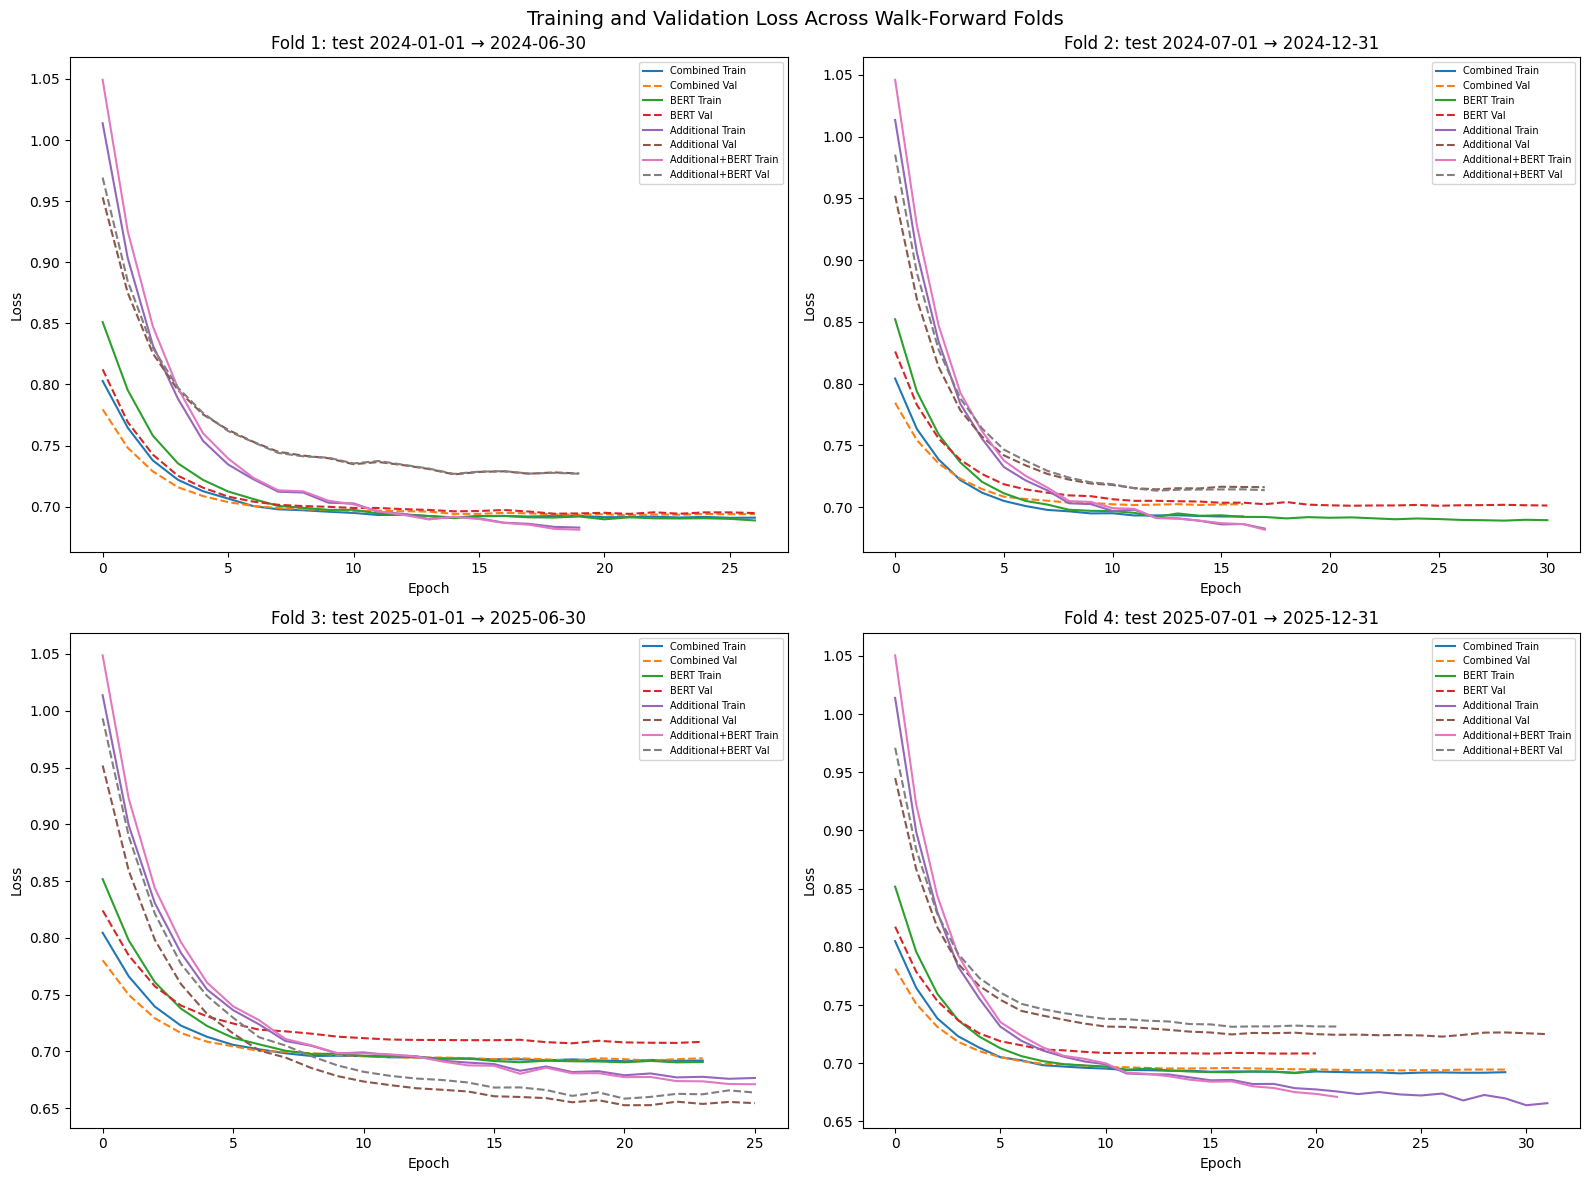

In [156]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Training and Validation Loss Across Walk-Forward Folds', fontsize=14)

for fold_idx, ax in enumerate(axes.flat):
    fold = walk_forward_folds[fold_idx]
    ax.set_title(f'Fold {fold_idx + 1}: test {fold["test_start"]} → {fold["test_end"]}')
    for model_name in ['Combined', 'BERT', 'Additional', 'Additional+BERT']:
        history = fold_histories[fold_idx][model_name]
        ax.plot(history.history['loss'], label=f'{model_name} Train')
        ax.plot(history.history['val_loss'], label=f'{model_name} Val', linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [157]:
# Export: one Excel per fold, one sheet per model, columns: Date / Actual / Predicted
# Reconstruct test dates using the same filter + clean + look_back logic as prepare_fold_data
feature_sets_map = {
    'Combined':        features_combined_data,
    'BERT':            features_bert,
    'Additional':      features_additional,
    'Additional+BERT': features_additional_bert,
}

source_dates = pd.to_datetime(oversampled_data['date']).reset_index(drop=True)

for fold_idx, fold in enumerate(walk_forward_folds):
    output_path = f'Classification_Fold{fold_idx+1}.xlsx'
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        for name, feat_df in feature_sets_map.items():
            test_mask = ((source_dates >= pd.Timestamp(fold['test_start'])) &
                         (source_dates <= pd.Timestamp(fold['test_end'])))
            feat_test = feat_df.reset_index(drop=True)[test_mask.values]
            clean = ~feat_test.isnull().any(axis=1)
            dates_test = source_dates[test_mask.values][clean.values].values[look_back:]

            y_test = fold_data[fold_idx][name][3]
            y_pred = np.argmax(fold_preds[fold_idx][name], axis=1)
            assert len(dates_test) == len(y_test) == len(y_pred), \
                f'Length mismatch for {name} fold {fold_idx+1}: dates={len(dates_test)}, y={len(y_test)}, pred={len(y_pred)}'

            df = pd.DataFrame({
                'Date':      pd.to_datetime(dates_test),
                'Actual':    y_test,
                'Predicted': y_pred,
            }).sort_values('Date').reset_index(drop=True)
            df.to_excel(writer, sheet_name=name[:31], index=False)
    print(f'Saved {output_path}')


Saved Classification_Fold1.xlsx
Saved Classification_Fold2.xlsx
Saved Classification_Fold3.xlsx
Saved Classification_Fold4.xlsx
